# 05 — Regime-adaptive trading

The naive mean-reversion strategy has a hard stop at 3.5σ. But the 2026 Hormuz crisis drove the Brent–WTI spread-z to **+12σ**. So the naive strategy shorts the spread at +2σ, gets *stopped out for a loss* at +3.5σ as the spread keeps widening, and then misses the eventual reversion. Presenting a serious tail-risk challenge.

To fix this I implemented a simple methodology:
- **Calm regime** → mean-revert normally.
- **Crisis regime** → do not fade early. Stand aside (or size down) until volatility rolls over, because the proven resilience suggests the reversion will come — just not on the timescale a 3.5σ stop can survive.

I test two adaptations against the naive baseline:
1. **Regime-gated** — suppress *new* entries while the spread is in a high-volatility crisis regime (existing positions still exit on revert/stop as before).
2. **Gated + vol-scaled** — additionally size each position inversely to realised volatility.

**Regime signal (no lookahead).** Crisis = 20-day realised volatility of the daily spread change above its trailing 252-day 80th percentile. All rolling stats are `shift(1)`-ed.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (11, 5), "axes.grid": True, "grid.alpha": 0.3})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_csv(ROOT / "data" / "processed" / "spread.csv", parse_dates=["date"]).set_index("date").sort_index()

L, ENTRY, EXIT, STOP, TD, OOS = 60, 2.0, 0.5, 3.5, 252, "2019-01-01"

s = df["spread"]
df["z"] = (s - s.rolling(L).mean().shift(1)) / s.rolling(L).std(ddof=1).shift(1)
df["d"] = s.diff()

# Crisis regime: 20d realised vol of d_spread above its trailing 1y 80th percentile (shifted, no lookahead)
rv = df["d"].rolling(20).std(ddof=1).shift(1)
df["crisis"] = (rv > rv.rolling(252).quantile(0.80).shift(1))
df = df.dropna(subset=["z", "d"]).copy()
df["crisis"] = df["crisis"].fillna(False)
print(f"rows={len(df)}  span={df.index.min().date()}..{df.index.max().date()}  crisis-days={int(df['crisis'].sum())} ({df['crisis'].mean():.1%})")

rows=9674  span=1987-08-14..2026-06-01  crisis-days=2424 (25.1%)


In [ ]:
def pos_naive(z):
    """Symmetric mean-reversion: enter at |z|>=ENTRY, exit at |z|<=EXIT or |z|>=STOP."""
    p = np.zeros(len(z)); c = 0
    for i, zi in enumerate(z):
        if c == 0:
            if zi <= -ENTRY: c = 1
            elif zi >= ENTRY: c = -1
        elif abs(zi) <= EXIT or abs(zi) >= STOP:
            c = 0
        p[i] = c
    return p

def pos_gated(z, cr):
    """Same logic, but block NEW entries while in the crisis regime."""
    p = np.zeros(len(z)); c = 0
    for i, zi in enumerate(z):
        if c == 0:
            if not cr[i]:
                if zi <= -ENTRY: c = 1
                elif zi >= ENTRY: c = -1
        elif abs(zi) <= EXIT or abs(zi) >= STOP:
            c = 0
        p[i] = c
    return p

zv, cr = df["z"].values, df["crisis"].values
df["p_naive"] = pd.Series(pos_naive(zv), index=df.index).shift(1).fillna(0)
df["p_gated"] = pd.Series(pos_gated(zv, cr), index=df.index).shift(1).fillna(0)

# Vol-scaled sizing on the gated strategy: size = clip(trailing-median RV / current RV, 0.25, 1.0)
rvn = df["d"].rolling(20).std(ddof=1).shift(1)
size = (rvn.rolling(252).median().shift(1) / rvn).clip(0.25, 1.0).fillna(1.0)
df["p_volscaled"] = df["p_gated"] * size

for p in ["p_naive", "p_gated", "p_volscaled"]:
    df[p.replace("p_", "pnl_")] = df[p] * df["d"]
df[["z", "crisis", "p_naive", "p_gated", "p_volscaled"]].tail()

,z,crisis,p_naive,p_gated,p_volscaled
date,,,,,
2026-05-26,-0.994364,True,0.0,0.0,0.0
2026-05-27,-1.045536,True,0.0,0.0,0.0
2026-05-28,-1.318599,False,0.0,0.0,0.0
2026-05-29,-1.467876,True,0.0,0.0,0.0
2026-06-01,-1.352591,True,0.0,0.0,0.0


## OOS performance (2019–2026)

Sharpe annualised at 252 trading days; PnL and drawdown in $/bbl of the dollar spread (gross of costs, as in notebook 03).

In [ ]:
def stats(pnl):
    sh = (pnl.mean() / pnl.std(ddof=1)) * np.sqrt(TD) if pnl.std() else np.nan
    eq = pnl.cumsum()
    return {"Sharpe": round(float(sh), 2), "Total PnL ($)": round(float(pnl.sum()), 1),
            "Max DD ($)": round(float((eq - eq.cummax()).min()), 1)}

oos = df[df.index >= OOS]
table = pd.DataFrame({
    "Naive (notebook 03)": stats(oos["pnl_naive"]),
    "Regime-gated": stats(oos["pnl_gated"]),
    "Gated + vol-scaled": stats(oos["pnl_volscaled"]),
}).T
table

,Sharpe,Total PnL ($),Max DD ($)
Naive (notebook 03),1.02,88.4,-26.0
Regime-gated,1.32,70.1,-5.6
Gated + vol-scaled,1.42,62.2,-4.6


## Where the edge comes from: crisis-window PnL

The adaptation should help most exactly where naive bleeds — the 2026 Hormuz crisis. COVID-2020 is shown as an honest counter-case (note: the 2020-04-20 negative-WTI print is dropped from the dataset, muting that window).

In [ ]:
windows = {"COVID 2020": ("2020-02-15", "2020-06-30"), "Hormuz 2026": ("2026-02-15", "2026-05-26")}
rows = {}
for name, (lo, hi) in windows.items():
    w = df[(df.index >= lo) & (df.index <= hi)]
    rows[name] = {"Naive": round(float(w["pnl_naive"].sum()), 2),
                  "Regime-gated": round(float(w["pnl_gated"].sum()), 2),
                  "Gated + vol-scaled": round(float(w["pnl_volscaled"].sum()), 2),
                  "crisis-days": int(w["crisis"].sum())}
pd.DataFrame(rows).T

,Naive,Regime-gated,Gated + vol-scaled,crisis-days
COVID 2020,8.51,1.78,0.59,39.0
Hormuz 2026,-2.87,0.85,0.54,66.0


## Equity curves

Cumulative OOS PnL for the three strategies, with crisis-regime days shaded. The naive curve's worst drawdown is the 2026 crisis; the adapted curves sit it out.

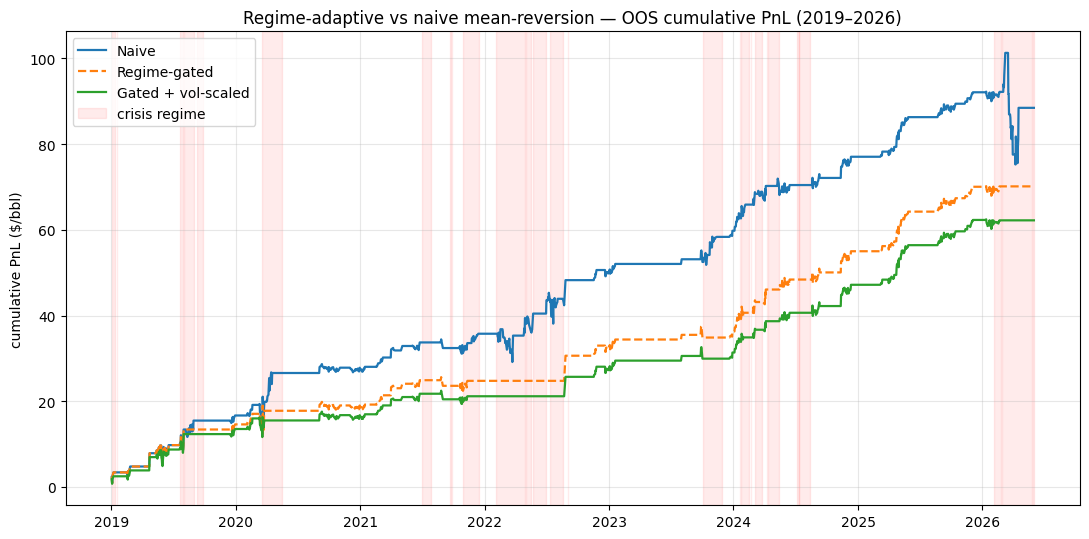

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for col, label, style in [("pnl_naive", "Naive", "-"), ("pnl_gated", "Regime-gated", "--"), ("pnl_volscaled", "Gated + vol-scaled", "-")]:
    ax.plot(oos.index, oos[col].cumsum(), style, label=label, linewidth=1.6)
# shade crisis-regime days
ymin, ymax = ax.get_ylim()
ax.fill_between(oos.index, ymin, ymax, where=oos["crisis"], color="red", alpha=0.08, label="crisis regime")
ax.set_ylim(ymin, ymax)
ax.set_title("Regime-adaptive vs naive mean-reversion — OOS cumulative PnL (2019–2026)")
ax.set_ylabel("cumulative PnL ($/bbl)"); ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(ROOT / "figures" / "fig_regime_adaptive.png", dpi=150, bbox_inches="tight")
plt.show()

## Read

- **The adaptation trades return for risk efficiency.** Regime-gating lifts the OOS Sharpe from **1.02 → 1.32** and cuts max drawdown from **−$26.0 → −$5.6** (a 78% reduction). Adding vol-scaling pushes Sharpe to **1.42** (max DD −$4.6) — the best risk-adjusted result.
- **Honest counter-case.** COVID-2020 is where the gate *costs* me: naive makes **+$8.51**, gating only **+$1.78**. There the spread dislocation was profitable to fade, and standing aside left money on the table. The regime gate is risk control, not a free lunch — it cannot know in advance whether a given crisis will revert quickly (COVID) or grind (Hormuz).

The adaptation converts the strategy's single worst failure mode (getting run over during the acute phase of a supply shock) into flat exposure, at the cost of some calm-regime and fast-reverting-crisis profit. Net: materially higher Sharpe, materially lower tail risk.